In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("crowd_data.csv")

df.head()

,place,state,region,rating,time,day,weekend,busy_score,crowd
0,Goa,Goa,West India,9,morning,Monday,0,20,Low
1,Goa,Goa,West India,9,morning,Wednesday,0,35,Low
2,Goa,Goa,West India,9,morning,Saturday,1,63,Medium
3,Goa,Goa,West India,9,morning,Sunday,1,44,Medium
4,Goa,Goa,West India,9,afternoon,Monday,0,52,Medium


In [3]:
print(df.shape)

(1200, 9)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   place       1200 non-null   object
 1   state       1200 non-null   object
 2   region      1200 non-null   object
 3   rating      1200 non-null   int64 
 4   time        1200 non-null   object
 5   day         1200 non-null   object
 6   weekend     1200 non-null   int64 
 7   busy_score  1200 non-null   int64 
 8   crowd       1200 non-null   object
dtypes: int64(3), object(6)
memory usage: 84.5+ KB
None


In [5]:
df["crowd"] = df["crowd"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [43]:
df["is_peak"] = df["time"].apply(lambda x: 1 if x == "afternoon" else 0)

df["weekend_peak"] = df["weekend"] * df["is_peak"]

df["high_popularity"] = df["rating"].apply(lambda x: 1 if x > 70 else 0)

In [45]:
df = df[[
    "place", "state", "region", "rating",
    "time", "day", "weekend",
    "is_peak", "high_popularity", "weekend_peak",
    "crowd"
]]

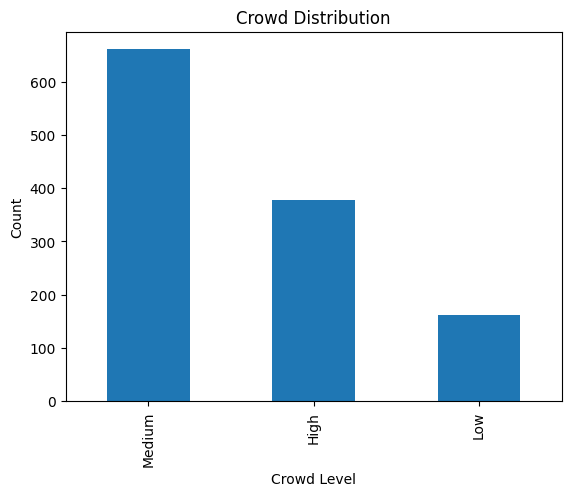

In [46]:
df = pd.read_csv("crowd_data.csv")

df["crowd"].value_counts().plot(kind="bar")
plt.title("Crowd Distribution")
plt.xlabel("Crowd Level")
plt.ylabel("Count")
plt.show()

df = pd.get_dummies(df)

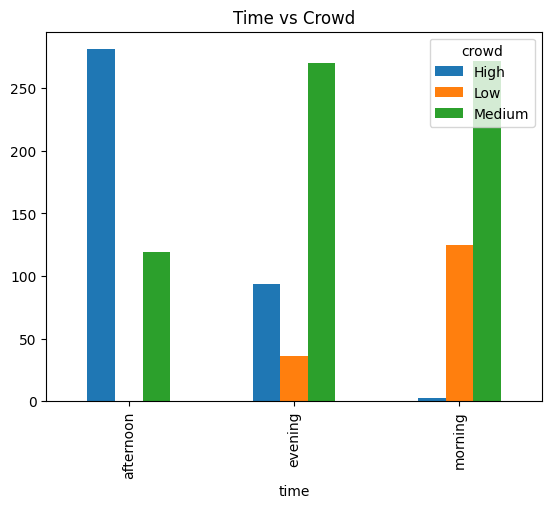

In [47]:
df = pd.read_csv("crowd_data.csv")

pd.crosstab(df["time"], df["crowd"]).plot(kind="bar")
plt.title("Time vs Crowd")
plt.show()

df = pd.get_dummies(df)

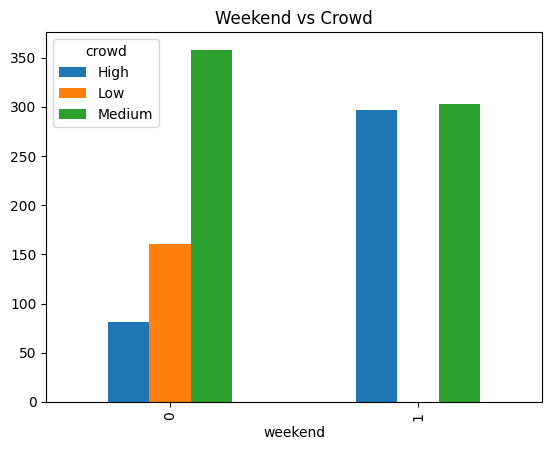

In [48]:
df = pd.read_csv("crowd_data.csv")

pd.crosstab(df["weekend"], df["crowd"]).plot(kind="bar")
plt.title("Weekend vs Crowd")
plt.show()

df = pd.get_dummies(df)

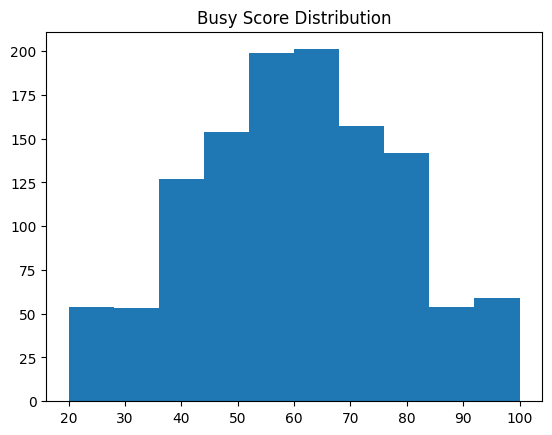

In [49]:
df = pd.read_csv("crowd_data.csv")

plt.hist(df["busy_score"])
plt.title("Busy Score Distribution")
plt.show()

df = pd.get_dummies(df)

In [50]:
df = pd.read_csv("crowd_data.csv")

y = df["crowd"]
X = df.drop(["crowd", "busy_score"], axis=1)

X = pd.get_dummies(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300,max_depth=20,min_samples_split=5,random_state=42)

In [53]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7875

Classification Report:
               precision    recall  f1-score   support

        High       0.90      0.70      0.78        86
         Low       0.59      0.59      0.59        22
      Medium       0.77      0.88      0.82       132

    accuracy                           0.79       240
   macro avg       0.75      0.72      0.73       240
weighted avg       0.80      0.79      0.79       240



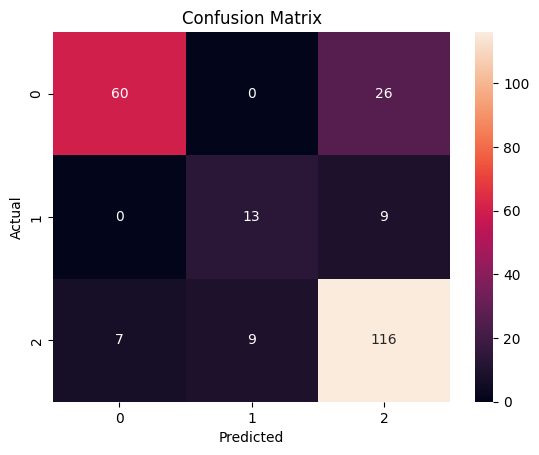

In [55]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

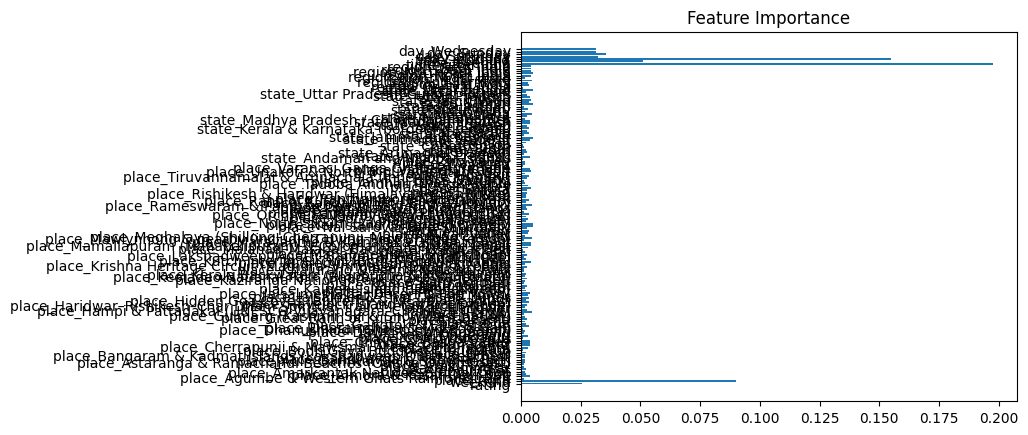

In [56]:
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [57]:
joblib.dump(model, "crowd_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

print(" Model saved successfully!")

 Model saved successfully!


In [71]:
def predict_crowd(input_data):
    import pandas as pd
    import joblib

    print("Input type:", type(input_data))

    if not isinstance(input_data, dict):
        raise ValueError("Input must be a dictionary")

    model = joblib.load("crowd_model.pkl")
    columns = joblib.load("model_columns.pkl")

    # Feature engineering
    time = input_data["time"]
    rating = input_data["rating"]
    weekend = input_data["weekend"]

    input_data["is_peak"] = 1 if time == "afternoon" else 0
    input_data["high_popularity"] = 1 if rating > 70 else 0
    input_data["weekend_peak"] = weekend * input_data["is_peak"]

    # Convert to DataFrame
    input_df = pd.DataFrame([input_data])

    # One-hot encoding
    input_df = pd.get_dummies(input_df)

    # Add missing columns
    for col in columns:
        if col not in input_df:
            input_df[col] = 0

    input_df = input_df[columns]

    # Predict
    prediction = model.predict(input_df)[0]

    return prediction

In [79]:
result = predict_crowd({
    "place": "Goa Beach",
    "state": "Goa",
    "region": "West",
    "rating": 85,
    "time": "afternoon",
    "day": "Sunday",
    "weekend": 1
})

print("Predicted Crowd:", result)

Input type: <class 'dict'>
Predicted Crowd: High


/tmp/ipykernel_427/3552167368.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[col] = 0
/tmp/ipykernel_427/3552167368.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[col] = 0
/tmp/ipykernel_427/3552167368.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[col] = 